In [2]:
import jax
import xarray as xr
import pyqg
import numpy as np
import jax.numpy as jnp

from matplotlib import pyplot as plt

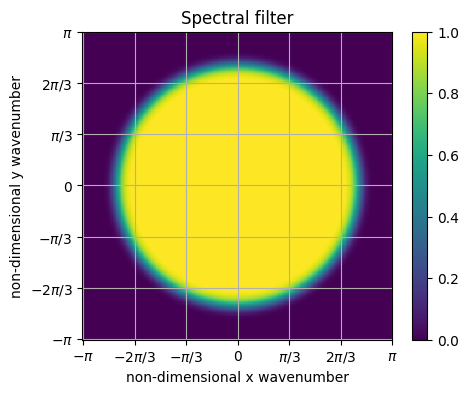

In [41]:
pi = np.pi
L = 1
nx, ny = 256, 256
dx = L / nx
dy = L / ny
filterfac = 23.6

# kk = 2 * pi / L * jnp.arange(nx // 2 + 1)  # zonal wavenumber
kk = jnp.fft.fftshift(2 * pi * jnp.fft.fftfreq(nx, d=dx))  # zonal wavenumber
ll = jnp.fft.fftshift(2 * pi * jnp.fft.fftfreq(ny, d=dy))  # meridional wavenumber

k, l_m = jnp.meshgrid(kk, ll)

kappa_sq = k**2 + l_m**2  # squared norm of the wavenumber

kstar = jnp.sqrt((k * dx) ** 2 + (l_m * dy) ** 2)
cutoff = 0.65 * pi
spec_filter = jnp.where(
    kstar <= cutoff,
    1.0,
    jnp.exp(-filterfac * (kstar - cutoff) ** 4),
)

plt.figure(figsize=(5, 4))
plt.pcolormesh(k * dx, l_m * dy, spec_filter)
plt.xlabel("non-dimensional x wavenumber")
plt.ylabel("non-dimensional y wavenumber")
labels = [
    r"$-\pi$",
    r"$-2\pi/3$",
    r"$-\pi/3$",
    r"$0$",
    r"$\pi/3$",
    r"$2\pi/3$",
    r"$\pi$",
]
plt.xticks(np.pi * np.arange(-1, 1.1, 1 / 3), labels=labels)
plt.yticks(np.pi * np.arange(-1, 1.1, 1 / 3), labels=labels)
plt.grid()
plt.colorbar()
plt.title("Spectral filter")
plt.savefig("../output/spectral_filter.png", dpi=300, bbox_inches="tight")

Text(0, 0.5, 'Time (s)')

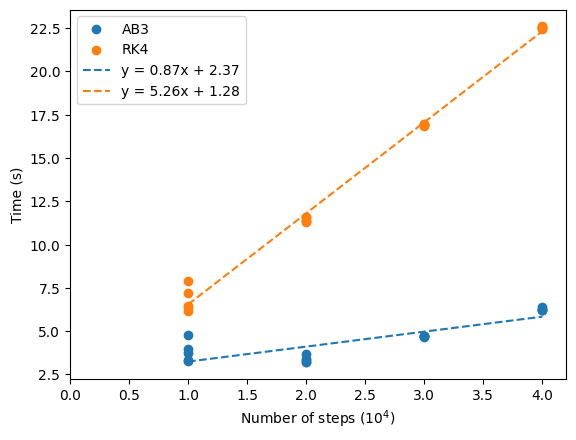

In [ ]:
import json
import scipy
import matplotlib.pyplot as plt

with open("../output/timestepper_benchmarks.json", "r") as f:
    results = json.load(f)

nsteps_scaling = 1e4
rk4_results = [
    [int(nsteps) / nsteps_scaling, time]
    for nsteps, data in results.items()
    for time in data["rk4"]
]
ab3_results = [
    [int(nsteps) / nsteps_scaling, time]
    for nsteps, data in results.items()
    for time in data["ab3"]
]
rk4_results = np.array(rk4_results)
ab3_results = np.array(ab3_results)

# linear fit
ab3_fit = scipy.stats.linregress(ab3_results[:, 0], ab3_results[:, 1])
rk4_fit = scipy.stats.linregress(rk4_results[:, 0], rk4_results[:, 1])
xvals = np.linspace(ab3_results[0, 0], ab3_results[-1, 0], 100)
ab3_line = ab3_fit.slope * xvals + ab3_fit.intercept
rk4_line = rk4_fit.slope * xvals + rk4_fit.intercept

plt.scatter(ab3_results[:, 0], ab3_results[:, 1], color="tab:blue", label="AB3")
plt.scatter(rk4_results[:, 0], rk4_results[:, 1], color="tab:orange", label="RK4")

plt.plot(
    xvals,
    ab3_line,
    color="tab:blue",
    linestyle="--",
    label=f"y = {ab3_fit.slope:.2f}x + {ab3_fit.intercept:.2f}",
)
plt.plot(
    xvals,
    rk4_line,
    color="tab:orange",
    linestyle="--",
    label=f"y = {rk4_fit.slope:.2f}x + {rk4_fit.intercept:.2f}",
)

plt.legend()
plt.xlim(0, ab3_results[-1, 0] + 0.2)
plt.grid()
plt.xlabel(r"Number of steps ($10^{4}$)")
plt.ylabel("Time (s)")
# plt.savefig("../output/timestepper_benchmarks.png", dpi=300, bbox_inches="tight")

In [24]:
ab3_fit

array([8.65401803e-05, 2.37357298e+00])

In [1]:
ds = xr.open_dataset("../output/examples/barotropic_rossby_wave.zarr", engine="zarr")
ds

NameError: name 'xr' is not defined

In [ ]:
nx, ny = 256, 256
Lx, Ly = 1e6, 1e6
Ld = 15000.0
hour = 3600  # sec
day = 24 * hour

T = 40 * day
dt = hour / 4
nsteps = int(T / dt)
interval_steps = 24

# initialize PV anomalies to a plane wave
x = np.linspace(0, Lx, nx, endpoint=False)
y = np.linspace(0, Ly, ny, endpoint=False)
xgrid, ygrid = np.meshgrid(x, y, indexing="xy")

k = 10 * (2 * np.pi / Lx)
l = 2 * (2 * np.pi / Ly)
print(f"k * Ld = {k * Ld}")
print(f"l * Ld = {l * Ld}")

gaussian_radius = Ly / 5
gaussian_envelope = np.exp(-((ygrid - Ly / 2) ** 2) / (gaussian_radius**2)) * np.exp(
    -((xgrid - Lx / 2) ** 2) / (gaussian_radius**2)
)
q_upper = -np.cos(k * xgrid + l * ygrid) * 1e-5  # * gaussian_envelope * 1e-5
q_lower = q_upper.copy()

pyqg_model = pyqg.QGModel(
    nx=nx, ny=ny, L=Ly, W=Lx, rd=Ld, delta=1.0, U1=0.0, U2=0.0, rek=0.0, tmax=T
)
pyqg_model.set_q1q2(q_upper, q_lower)

for _ in pyqg_model.run_with_snapshots(tsnapstart=0, tsnapint=10):
    plt.pcolormesh(pyqg_model.q[0, :, :])
    plt.colorbar()
    plt.show()

In [ ]:
plt.pcolormesh(pyqg_model.q[0, :, :])

In [ ]:
ds = xr.open_dataset("../output/examples/barotropic_rossby_wave.zarr", engine="zarr")
ds

In [ ]:
ds["psi"].isel(time=40).sel(lev=0).plot()

In [ ]:
time = 0

q = ds["q"].isel(time=time, lev=0)
u = ds["u"].isel(time=time, lev=0)
v = ds["v"].isel(time=time, lev=0)

plt.pcolormesh(ds["x"] / 1000, ds["y"] / 1000, q, cmap="RdBu_r", vmin=-2e-5, vmax=2e-5)
plt.colorbar()
plt.quiver(ds["x"][::10] / 1000, ds["y"][::10] / 1000, u[::10, ::10], v[::10, ::10])

In [ ]:
def second_derivative(da, dim):
    """
    Estimate the second derivative of a periodic DataArray
    along a given dimension.
    """

    dx = da[dim].diff(dim)[0].values

    return (da.roll({dim: 1}) + da.roll({dim: -1}) - 2 * da) / dx**2


beta = ds.attrs["beta"]
(beta - second_derivative(u, "y")).plot()